### Library

In [2]:
import time
import json
import random
import requests
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from datetime import datetime
from flask import Flask, request, jsonify
from matplotlib.animation import FuncAnimation
from IPython.display import display, clear_output
from collections import deque

### Loading the preprocessed Dataset and Configuration

In [3]:
df = pd.read_csv("cleaned_sensor_data.csv")
csv_path = "cleaned_sensor_data"
Api_Endpoint = "http://localhost:5000/predict"
DELAY = 1
results = []

### Detection Model and Sensor Streaming

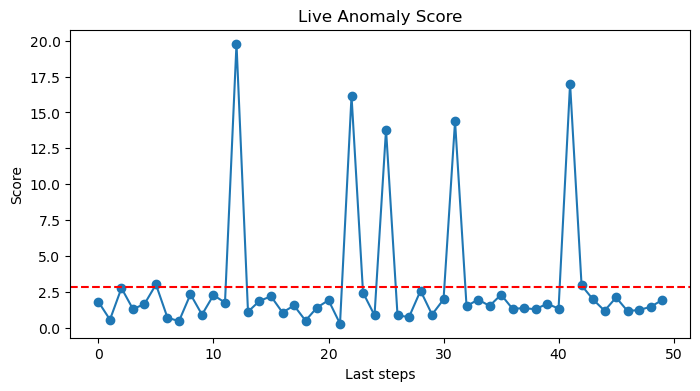

Anomaly score: 1.9216901086870761


In [ ]:
WINDOW = 50
threshold = 2.80
 
scores = deque(maxlen=WINDOW)

def inject_anomaly(payload):
    payload = payload.copy()

    payload["temperature"] *= random.uniform(1.5, 2.0)
    payload["humidity"] *= random.uniform(0.3, 0.6)
    payload["sound"] *= random.uniform(2.0, 3.0)

    return payload
while True:
 
    for _, row in df.iterrows():
 
        payload = {
            "temperature": row["Temp"],
            "humidity": row["Humidity"],
            "sound": row["Sound"]
        }
 
        if random.random() < 0.05:
            payload = inject_anomaly(payload)
 
        response = requests.post(Api_Endpoint, json=payload)
        result = response.json()
 
        score = result.get("anomaly_score")
        scores.append(score)
 
        
        clear_output(wait=True)
 
        fig, ax = plt.subplots(figsize=(8, 4))
 
        ax.plot(list(scores), marker="o")
        ax.axhline(threshold, linestyle="--", color="red")
 
        ax.set_title("Live Anomaly Score")
        ax.set_xlabel("Last steps")
        ax.set_ylabel("Score")
 
        display(fig)
        plt.close(fig)
    
 
        print("Anomaly score:", score)
 
        time.sleep(DELAY)